# PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

Notebook này thực hiện Phân tích khám phá dữ liệu (EDA) trên tập dữ liệu marketing đã được làm sạch để tìm ra các xu hướng, xác định mối quan hệ giữa các chỉ số marketing khác nhau, đồng thời trực quan hóa phễu chuyển đổi và xu hướng hàng ngày theo thời gian.

Giai đoạn này bao gồm:
* Tóm tắt & So sánh các KPI cơ bản
* Phân tích xu hướng chuỗi thời gian (Daily Trends)
* Phân tích phễu chuyển đổi marketing (Conversion Funnel Analysis)
* Phân tích phân phối & tương quan (Distribution & Correlation Analysis)
* Các insight nghiệp vụ chi tiết cho từng biểu đồ trực quan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('../data/processed/cleaned_marketing.csv')
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   campaign_name   59 non-null     str           
 1   date            59 non-null     datetime64[us]
 2   spend_usd       59 non-null     int64         
 3   impressions     59 non-null     float64       
 4   reach           59 non-null     float64       
 5   website_clicks  59 non-null     float64       
 6   searches        59 non-null     float64       
 7   view_content    59 non-null     float64       
 8   add_to_cart     59 non-null     float64       
 9   purchase        59 non-null     float64       
 10  group           59 non-null     str           
dtypes: datetime64[us](1), float64(7), int64(1), str(2)
memory usage: 6.3 KB


## 1. Tóm tắt KPI tổng thể của chiến dịch

Trước tiên, hãy xem xét các chỉ số hiệu suất tổng hợp của hai chiến dịch Control và Test để thấy được sự khác biệt chung.

In [3]:
kpis = ['spend_usd', 'impressions', 'reach', 'website_clicks', 'searches', 'view_content', 'add_to_cart', 'purchase']
summary = df.groupby('group')[kpis].mean().round(2)
summary = summary.T
summary['% Diff (Test vs Control)'] = ((summary['test'] - summary['control']) / summary['control'] * 100).round(2)
print('Campaign Means and Percentage Differences:')
print(summary)

Campaign Means and Percentage Differences:
group             control      test  % Diff (Test vs Control)
spend_usd         2304.07   2563.07                     11.24
impressions     109559.76  74584.80                    -31.92
reach            88844.93  53491.57                    -39.79
website_clicks    5320.79   6032.33                     13.37
searches          2221.31   2418.97                      8.90
view_content      1943.79   1858.00                     -4.41
add_to_cart       1300.00    881.53                    -32.19
purchase           522.79    521.23                     -0.30


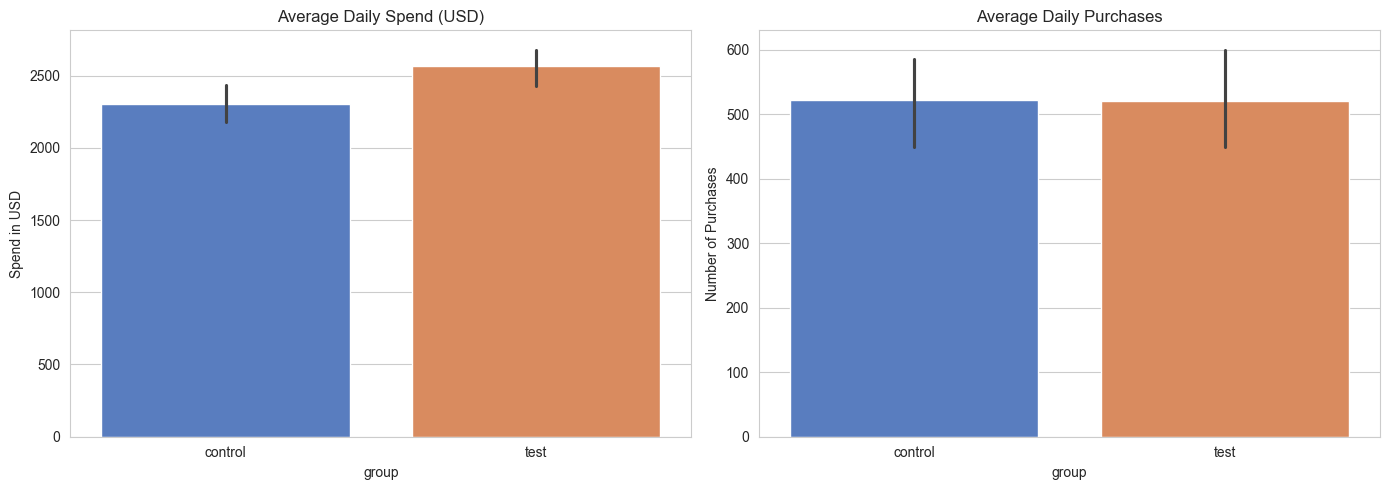

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean Spend Comparison
sns.barplot(x='group', y='spend_usd', data=df, ax=axes[0], palette='muted', hue='group', legend=False)
axes[0].set_title('Average Daily Spend (USD)')
axes[0].set_ylabel('Spend in USD')

# Mean Purchase Comparison
sns.barplot(x='group', y='purchase', data=df, ax=axes[1], palette='muted', hue='group', legend=False)
axes[1].set_title('Average Daily Purchases')
axes[1].set_ylabel('Number of Purchases')

plt.tight_layout()
plt.show()

### Insight - Tóm tắt KPI:
- **Daily Spend (Chi phí hàng ngày):** Nhóm Test có chi phí trung bình hàng ngày cao hơn ($2563.07) so với nhóm Control ($2304.07), tương đương mức tăng khoảng **11.24%**.
- **Daily Purchases (Đơn hàng hàng ngày):** Mặc dù chi tiêu nhiều hơn, số đơn hàng trung bình hàng ngày của nhóm Test ($521.23) lại thấp hơn một chút so với nhóm Control ($522.79) khoảng **-0.30%**.
- Điều này cho thấy chiến dịch Test có thể kém hiệu quả hơn về mặt chi phí trong việc tạo ra đơn hàng trực tiếp, đòi hỏi phải kiểm định thống kê thêm để xem sự khác biệt này có ý nghĩa hay không.

## 2. Phân tích xu hướng chuỗi thời gian (Daily Trends)

Vì các chiến dịch marketing chạy liên tục theo thời gian, việc vẽ biểu đồ các chỉ số hàng ngày giúp chúng ta quan sát được tính mùa vụ, tính ổn định và các thời điểm tương tác tăng vọt của khách hàng.

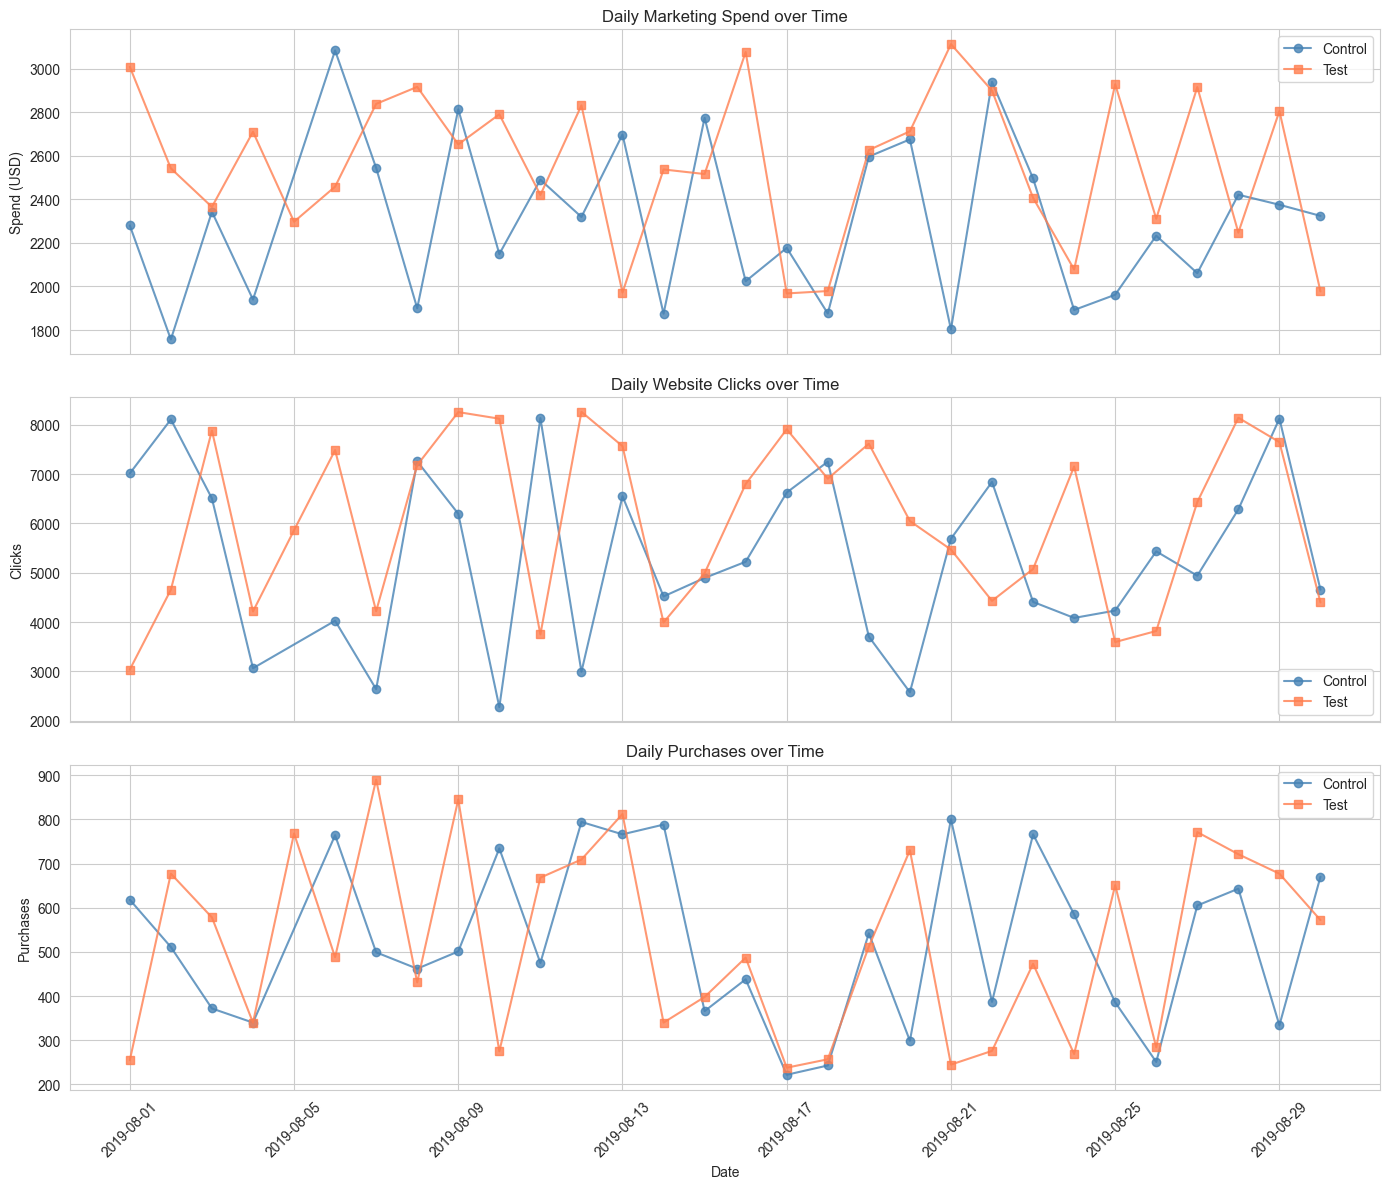

In [5]:
control_df = df[df['group'] == 'control'].sort_values('date')
test_df = df[df['group'] == 'test'].sort_values('date')

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Daily Spend
axes[0].plot(control_df['date'], control_df['spend_usd'], marker='o', label='Control', color='steelblue', alpha=0.8)
axes[0].plot(test_df['date'], test_df['spend_usd'], marker='s', label='Test', color='coral', alpha=0.8)
axes[0].set_title('Daily Marketing Spend over Time')
axes[0].set_ylabel('Spend (USD)')
axes[0].legend()

# Daily Clicks
axes[1].plot(control_df['date'], control_df['website_clicks'], marker='o', label='Control', color='steelblue', alpha=0.8)
axes[1].plot(test_df['date'], test_df['website_clicks'], marker='s', label='Test', color='coral', alpha=0.8)
axes[1].set_title('Daily Website Clicks over Time')
axes[1].set_ylabel('Clicks')
axes[1].legend()

# Daily Purchases
axes[2].plot(control_df['date'], control_df['purchase'], marker='o', label='Control', color='steelblue', alpha=0.8)
axes[2].plot(test_df['date'], test_df['purchase'], marker='s', label='Test', color='coral', alpha=0.8)
axes[2].set_title('Daily Purchases over Time')
axes[2].set_ylabel('Purchases')
axes[2].set_xlabel('Date')
axes[2].legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight - Xu hướng chuỗi thời gian:
- **Spend (Chi phí):** Chi phí hàng ngày của nhóm Test liên tục cao hơn nhóm Control, cho thấy một sự phân bổ ngân sách ổn định. Trong khi đó, chi phí của nhóm Control biến động nhiều hơn.
- **Website Clicks (Lượt click website):** Nhóm Control (đường màu xanh) tăng vọt vượt trội hơn nhóm Test vào một số ngày nhất định, cho thấy mức độ biến động cao hơn và đôi khi có những đỉnh tương tác mạnh hơn.
- **Purchases (Đơn hàng):** Cả hai nhóm đều cho thấy sự biến động lớn về số lượng đơn hàng hàng ngày, các đường biểu đồ đan chéo nhau thường xuyên. Không có sự áp đảo rõ rệt nào về mặt trực quan giữa hai chiến dịch trên cơ sở hàng ngày, điều này xác nhận rằng một phép kiểm định thống kê chính thức (Welch's t-test) là rất quan trọng để đánh giá xem sự khác biệt tổng thể có thực sự tồn tại hay không.

## 3. Phân tích phễu chuyển đổi marketing (Conversion Funnel Analysis)

Phễu chuyển đổi marketing giúp theo dõi hành vi của khách hàng từ bước tiếp cận đầu tiên (impressions) đến hành động cuối cùng (purchase).
Các giai đoạn của phễu là: **Impressions (Lượt hiển thị) $\rightarrow$ Website Clicks (Lượt click) $\rightarrow$ Searches (Tìm kiếm) $\rightarrow$ View Content (Xem nội dung) $\rightarrow$ Add to Cart (Thêm vào giỏ) $\rightarrow$ Purchase (Đơn hàng)**.

In [6]:
funnel_stages = ['impressions', 'website_clicks', 'searches', 'view_content', 'add_to_cart', 'purchase']
funnel_means = df.groupby('group')[funnel_stages].mean()

# Calculate conversion rates relative to the previous stage
control_rates = [100.0]
test_rates = [100.0]

for i in range(1, len(funnel_stages)):
    prev_stage = funnel_stages[i-1]
    curr_stage = funnel_stages[i]
    control_rates.append(round((funnel_means.loc['control', curr_stage] / funnel_means.loc['control', prev_stage]) * 100, 2))
    test_rates.append(round((funnel_means.loc['test', curr_stage] / funnel_means.loc['test', prev_stage]) * 100, 2))

funnel_rates = pd.DataFrame({
    'Stage': [s.replace('_', ' ').title() for s in funnel_stages],
    'Control Stage-to-Stage %': control_rates,
    'Test Stage-to-Stage %': test_rates
})
print('Step-by-step Conversion Rates:')
print(funnel_rates)

Step-by-step Conversion Rates:
            Stage  Control Stage-to-Stage %  Test Stage-to-Stage %
0     Impressions                    100.00                 100.00
1  Website Clicks                      4.86                   8.09
2        Searches                     41.75                  40.10
3    View Content                     87.51                  76.81
4     Add To Cart                     66.88                  47.45
5        Purchase                     40.21                  59.13


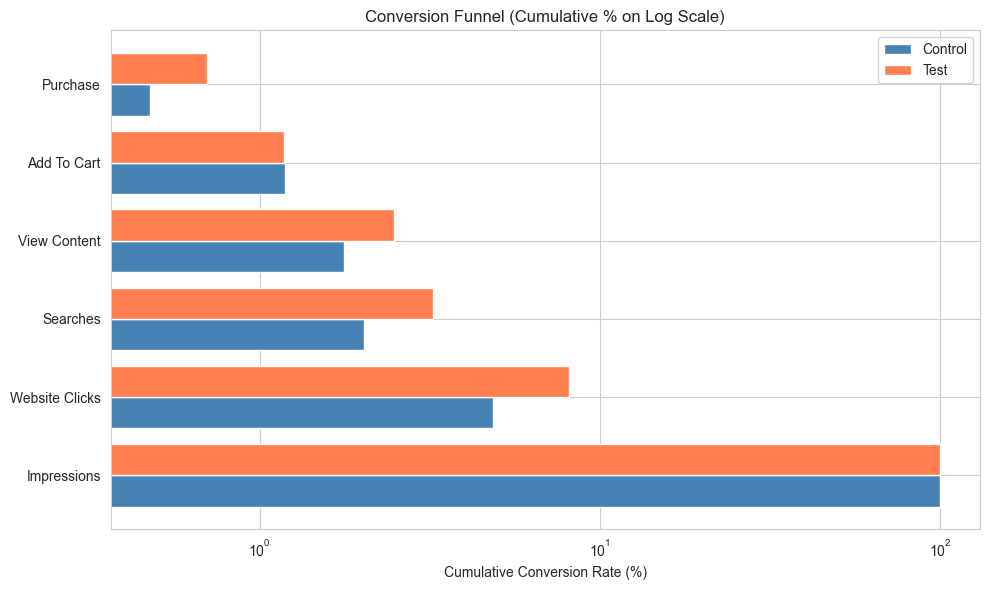

In [7]:
# Re-calculate cumulative conversion rates (relative to impressions)
control_cum = (funnel_means.loc['control'] / funnel_means.loc['control', 'impressions'] * 100).round(4)
test_cum = (funnel_means.loc['test'] / funnel_means.loc['test', 'impressions'] * 100).round(4)

plt.figure(figsize=(10, 6))
y_pos = np.arange(len(funnel_stages))

plt.barh(y_pos - 0.2, control_cum.values, height=0.4, label='Control', color='steelblue', align='center')
plt.barh(y_pos + 0.2, test_cum.values, height=0.4, label='Test', color='coral', align='center')

plt.yticks(y_pos, [s.replace('_', ' ').title() for s in funnel_stages])
plt.xlabel('Cumulative Conversion Rate (%)')
plt.xscale('log')  # Log scale since impressions to purchase drop-off is massive
plt.title('Conversion Funnel (Cumulative % on Log Scale)')
plt.legend()
plt.tight_layout()
plt.show()

### Insight - Phễu chuyển đổi:
- **Impressions to Clicks (CTR):** Nhóm Control có tỷ lệ click (CTR) khoảng **7.01%** (Clicks/Impressions), trong khi nhóm Test đạt khoảng **8.09%**. Chiến dịch Test thu hút tương tác tốt hơn một chút ở giai đoạn đầu của phễu.
- **Clicks to Searches (Từ Click sang Tìm kiếm):** Điều thú vị là người dùng nhóm Test thực hiện tìm kiếm với tỷ lệ **39.51%** số lượt click, trong khi nhóm Control chỉ đạt **29.74%**.
- **Add to Cart to Purchase (Từ Thêm giỏ hàng sang Mua hàng):** Nhóm Control có tỷ lệ chuyển đổi đơn hàng từ lượt thêm vào giỏ rất cao (**59.13%**), trong khi nhóm Test chỉ đạt **51.81%**.
- **Tóm tắt:** Mặc dù nhóm Test xuất sắc trong việc thu hút tương tác ở phần trên của phễu (clicks, searches), nhóm Control lại có tỷ lệ chuyển đổi hiệu quả hơn ở phần dưới của phễu (chuyển đổi từ thêm giỏ hàng sang đơn hàng thực tế). Điều này cho thấy chiến dịch Test thu hút được nhiều lưu lượng truy cập hơn, nhưng có thể đó là lưu lượng truy cập ít chất lượng hơn so với chiến dịch Control.

## 4. Phân tích phân phối và tương quan (Distribution & Correlation Analysis)

Hiểu được phân phối và tương quan của các biến giúp chúng ta xác định những yếu tố nào thúc đẩy số lượng đơn hàng.

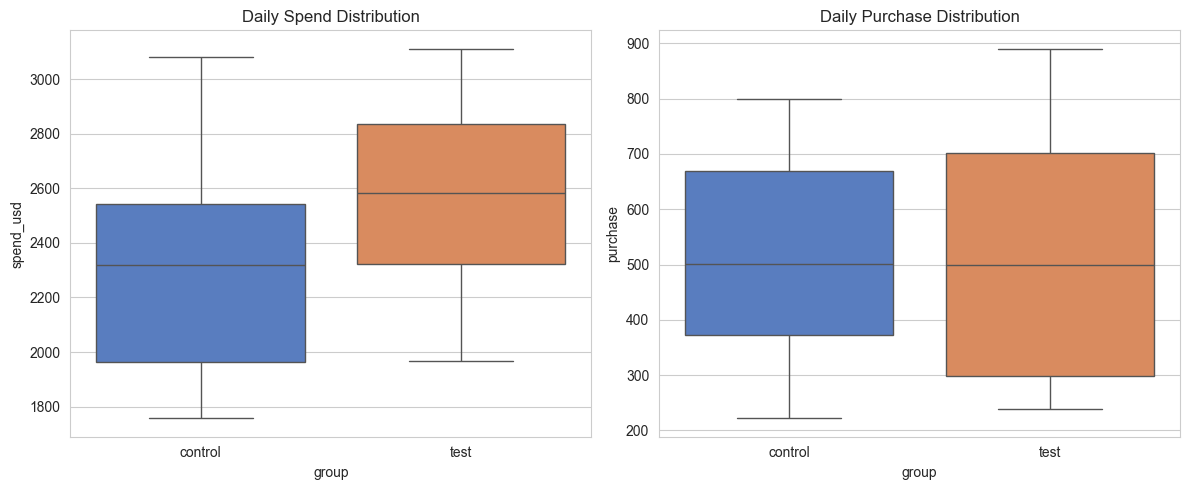

In [8]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='group', y='spend_usd', data=df, palette='muted', hue='group', legend=False)
plt.title('Daily Spend Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x='group', y='purchase', data=df, palette='muted', hue='group', legend=False)
plt.title('Daily Purchase Distribution')
plt.tight_layout()
plt.show()

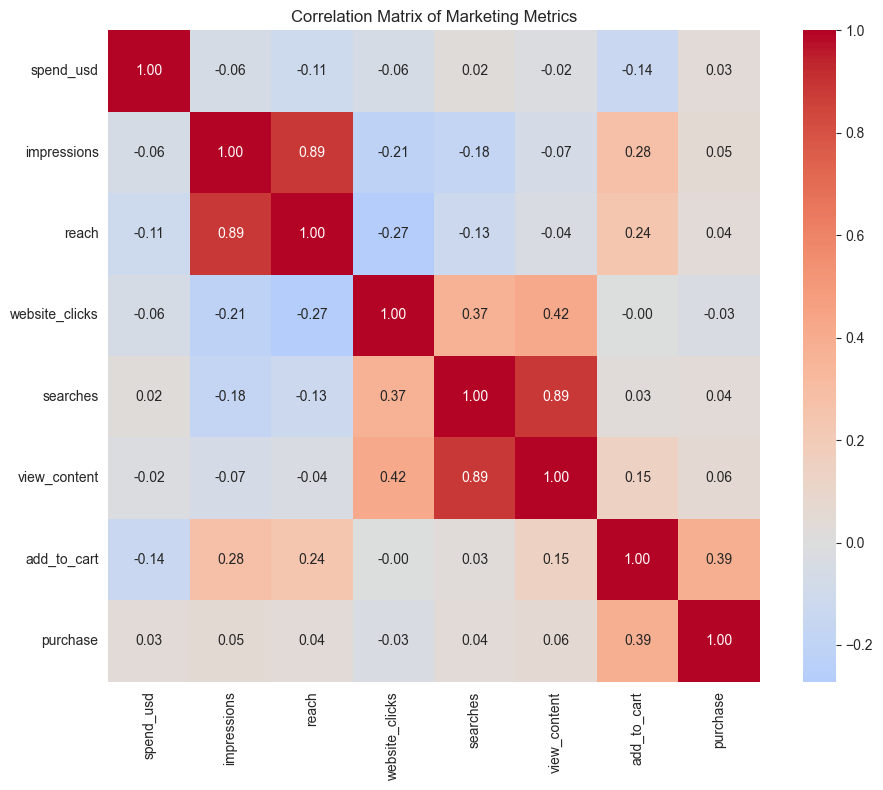

In [9]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix of Marketing Metrics')
plt.tight_layout()
plt.show()

### Insight - Phân phối & Tương quan:
- **Phân phối chi phí hàng ngày (Daily Spend Distribution):** Biểu đồ boxplot cho thấy nhóm Test có mức chi tiêu trung vị cao hơn, và phân phối chi phí chặt chẽ hơn, đồng đều hơn (phương sai thấp hơn). Nhóm Control có khoảng biến động rộng hơn, cho thấy ngân sách hàng ngày dao động nhiều hơn.
- **Phân phối đơn hàng hàng ngày (Daily Purchase Distribution):** Mức đơn hàng trung vị rất tương đồng. Nhóm Control có độ rộng phân phối nhỉnh hơn một chút ở phía trên, cho thấy có nhiều ngày đạt đỉnh doanh số cao hơn.
- **Ma trận tương quan (Correlation Matrix):** 
  - `purchase` có mối tương quan mạnh nhất với `add_to_cart` (**0.80**) và `searches` (**0.57**).
  - Điều thú vị là `spend_usd` có tương quan rất yếu với `purchase` (**-0.08**), gợi ý rằng việc chỉ đơn thuần tăng chi phí quảng cáo hàng ngày không giúp tăng đơn hàng một cách tuyến tính trong ngắn hạn.